In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv(r'sp500sub.csv', index_col = 'Date', parse_dates = True)

In [3]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Name
Date,,,,,,,
2010-01-04,9.22,9.51,9.17,9.50,9.50,1865400.0,INCY
2010-01-05,9.51,10.29,9.45,10.27,10.27,7608900.0,INCY
2010-01-06,10.38,11.09,10.35,11.00,11.00,8046700.0,INCY
2010-01-07,11.00,11.06,10.62,10.82,10.82,3680300.0,INCY
2010-01-08,10.82,11.00,10.75,10.94,10.94,1529300.0,INCY


In [4]:
goog = df[df['Name']=='GOOG'][['Close']].copy()

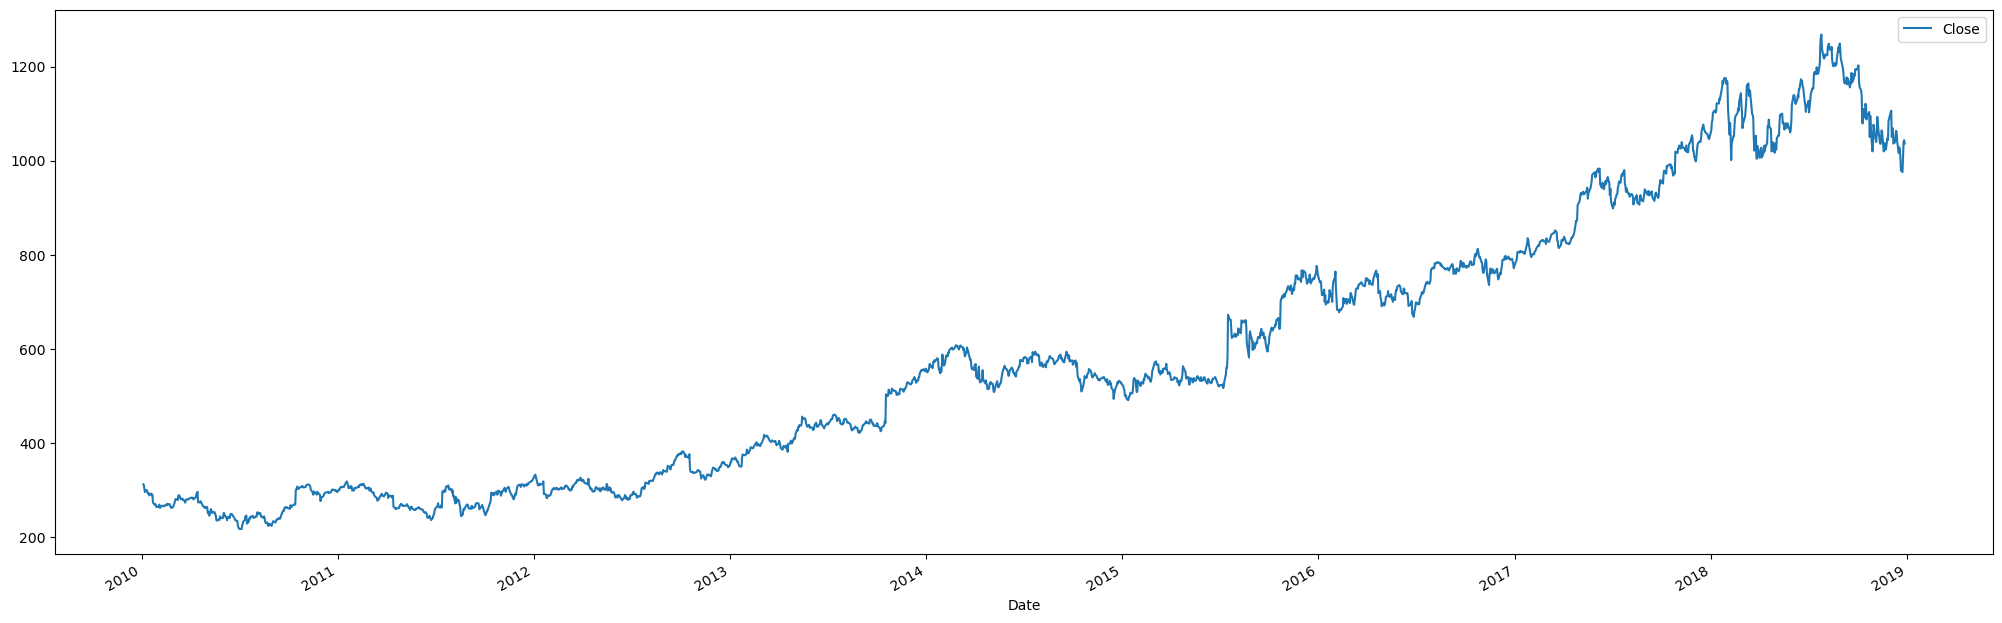

In [5]:
goog.plot(figsize = (25,8));

In [6]:
# goog.to_clipboard()

array([[<Axes: title={'center': 'Close'}>]], dtype=object)

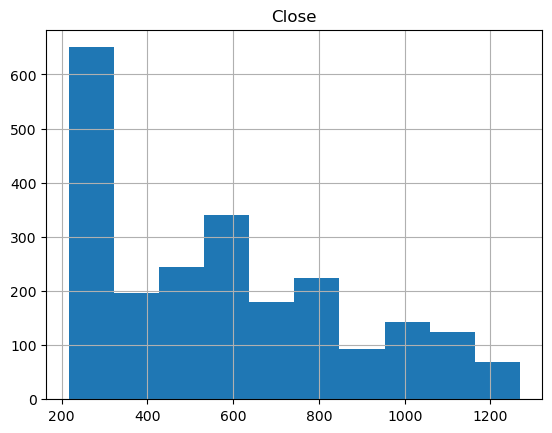

In [7]:
goog.hist()

In [8]:
goog['LogClose'] = np.log(goog['Close'])

In [9]:
""" note that we didnt require to take log here since , we could have used boxcox inside holt winter and set lambda = 0 for log transform"""

' note that we didnt require to take log here since , we could have used boxcox inside holt winter and set lambda = 0 for log transform'

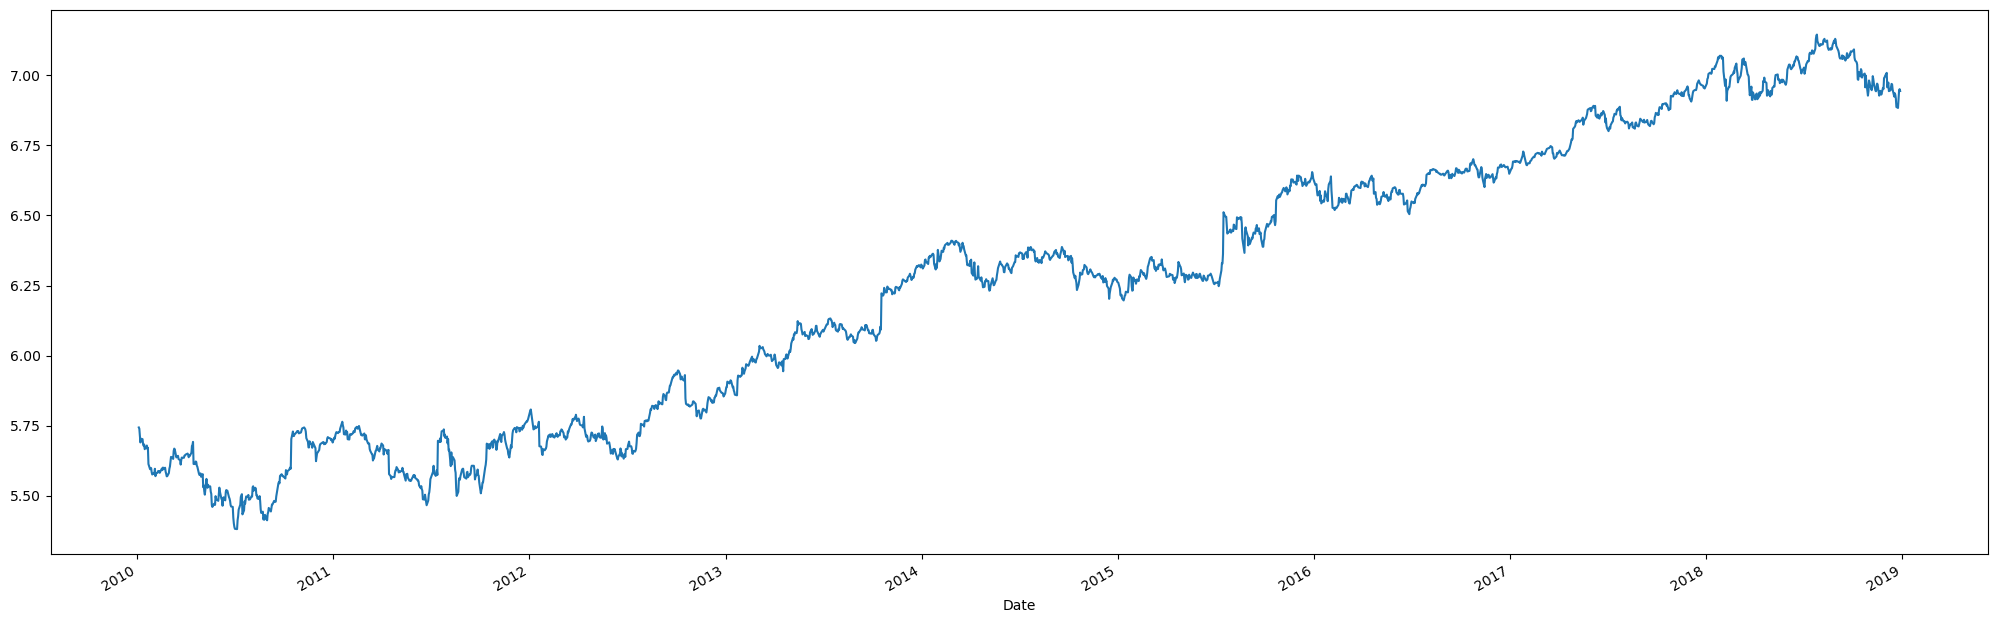

In [10]:
goog['LogClose'].plot(figsize = (25,8));

In [11]:
""" the trend now looks pretty linear.
we also plot the distribution of the log price - it happens to be evenly distributed. 
but we should not be aiming for this to be normally or uniformly distributed """

' the trend now looks pretty linear.\nwe also plot the distribution of the log price - it happens to be evenly distributed. \nbut we should not be aiming for this to be normally or uniformly distributed '

<Axes: >

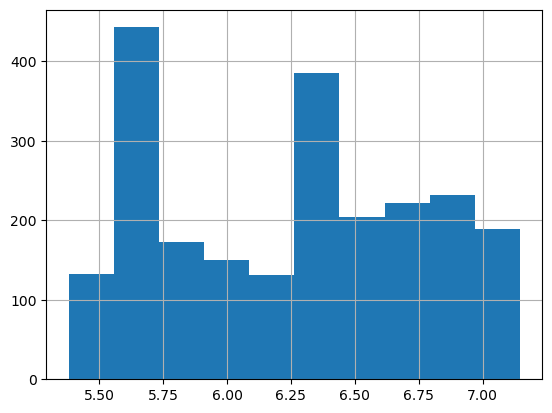

In [12]:
goog['LogClose'].hist()

In [13]:
goog.index

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2018-12-14', '2018-12-17', '2018-12-18', '2018-12-19',
               '2018-12-20', '2018-12-21', '2018-12-24', '2018-12-26',
               '2018-12-27', '2018-12-28'],
              dtype='datetime64[ns]', name='Date', length=2263, freq=None)

In [14]:
# goog.index.freq = 'B' 

""" B means business days - not all business days present since holidays can happen on weekdays as well"""

""" this will not work since not all days data is present since stock pmarket closed on weekends and also on holidays
also this will throw an error"""

' this will not work since not all days data is present since stock pmarket closed on weekends and also on holidays\nalso this will throw an error'

In [15]:
Ntest = 30
train =  goog.iloc[:-Ntest]
test = goog.iloc[-Ntest:]

train_idx = goog.index <= train.index[-1]
test_idx = goog.index > train.index[-1]

In [16]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [17]:
hw = ExponentialSmoothing(
    train['LogClose'],
    initialization_method = 'legacy-heuristic', # optional - do it if u want to replicate the result which u wanted from earlier version of statsmodels,
    trend = 'add', seasonal = None) # no seasonality assumed in stock prices
res_hw = hw.fit()



C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [18]:
""" warning coming up since our dataframe doesnt have a frequency"""

' warning coming up since our dataframe doesnt have a frequency'

In [19]:
res_hw.fittedvalues

Date
2010-01-04    5.739246
2010-01-05    5.739271
2010-01-06    5.734857
2010-01-07    5.709206
2010-01-08    5.685543
                ...   
2018-11-07    6.962087
2018-11-08    6.997260
2018-11-09    6.987099
2018-11-12    6.971886
2018-11-13    6.945586
Length: 2233, dtype: float64

In [20]:
res_hw.forecast(Ntest)

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


2233    6.943085
2234    6.943000
2235    6.942915
2236    6.942829
2237    6.942744
2238    6.942659
2239    6.942574
2240    6.942488
2241    6.942403
2242    6.942318
2243    6.942232
2244    6.942147
2245    6.942062
2246    6.941976
2247    6.941891
2248    6.941806
2249    6.941720
2250    6.941635
2251    6.941550
2252    6.941464
2253    6.941379
2254    6.941294
2255    6.941209
2256    6.941123
2257    6.941038
2258    6.940953
2259    6.940867
2260    6.940782
2261    6.940697
2262    6.940611
dtype: float64

In [21]:
""" note that since our dataframe doesnt have frequency set, look at the index of generated output, it is numbers as opposed to dates.
in comparison, look at train data prediction, it has dates.
not having index messes up the output of the prediction
"""


' note that since our dataframe doesnt have frequency set, look at the index of generated output, it is numbers as opposed to dates.\nin comparison, look at train data prediction, it has dates.\nnot having index messes up the output of the prediction\n'

In [22]:
res_hw.forecast(Ntest).to_numpy()

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


array([6.94308542, 6.94300011, 6.94291479, 6.94282948, 6.94274417,
       6.94265886, 6.94257355, 6.94248823, 6.94240292, 6.94231761,
       6.9422323 , 6.94214699, 6.94206167, 6.94197636, 6.94189105,
       6.94180574, 6.94172042, 6.94163511, 6.9415498 , 6.94146449,
       6.94137918, 6.94129386, 6.94120855, 6.94112324, 6.94103793,
       6.94095262, 6.9408673 , 6.94078199, 6.94069668, 6.94061137])

In [23]:
res_hw.fittedvalues

Date
2010-01-04    5.739246
2010-01-05    5.739271
2010-01-06    5.734857
2010-01-07    5.709206
2010-01-08    5.685543
                ...   
2018-11-07    6.962087
2018-11-08    6.997260
2018-11-09    6.987099
2018-11-12    6.971886
2018-11-13    6.945586
Length: 2233, dtype: float64

In [24]:
train.shape

(2233, 2)

In [25]:
goog.loc[train_idx, "HoltWintersTrain"] = res_hw.fittedvalues
goog.loc[test_idx, "HoltWintersTest"] = res_hw.forecast(Ntest).to_numpy()

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


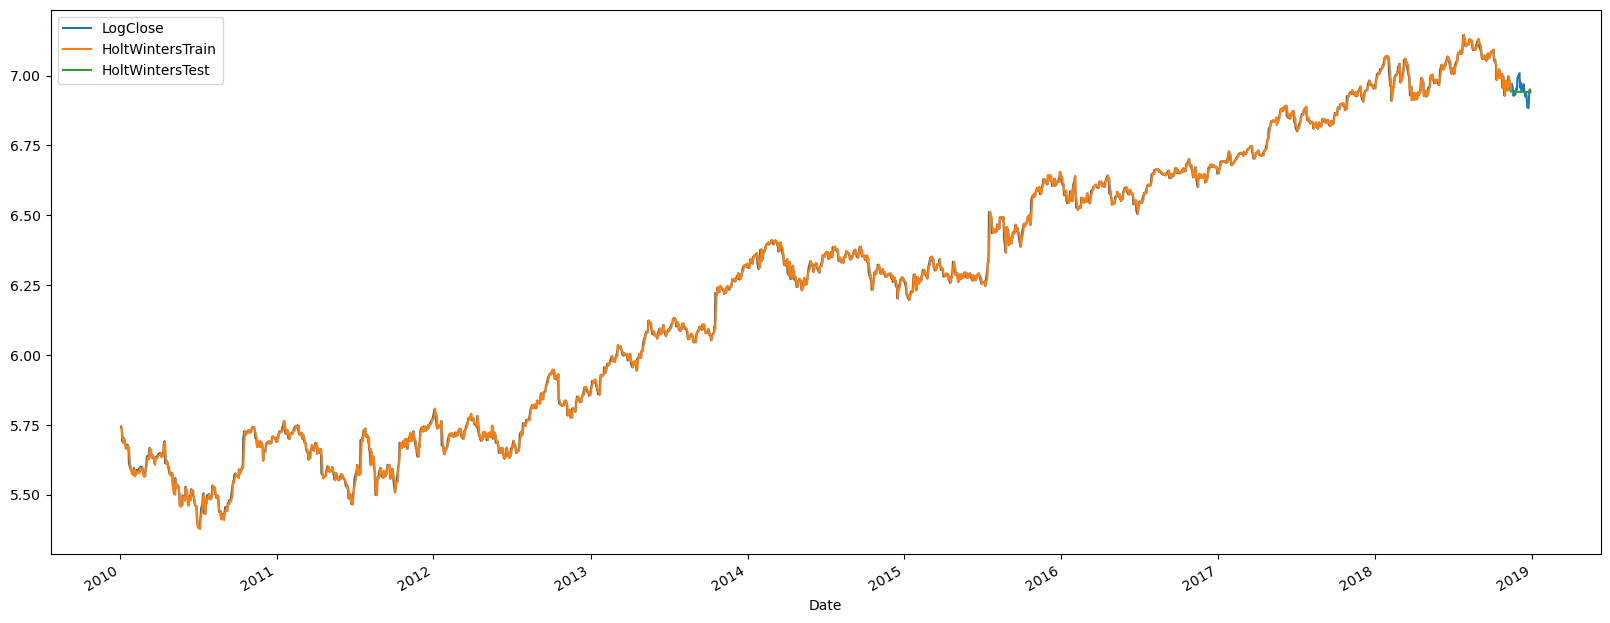

In [26]:
goog[['LogClose','HoltWintersTrain','HoltWintersTest']].plot(figsize = (20,8));

In [27]:
res_hw.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(0.0056528553049584335),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(5.743659296078559),
 'initial_trend': np.float64(-0.004413396708284445),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [28]:
"looking at the level parameters alpha, clearly it is naive forecast - since alpha is around 1"

'looking at the level parameters alpha, clearly it is naive forecast - since alpha is around 1'

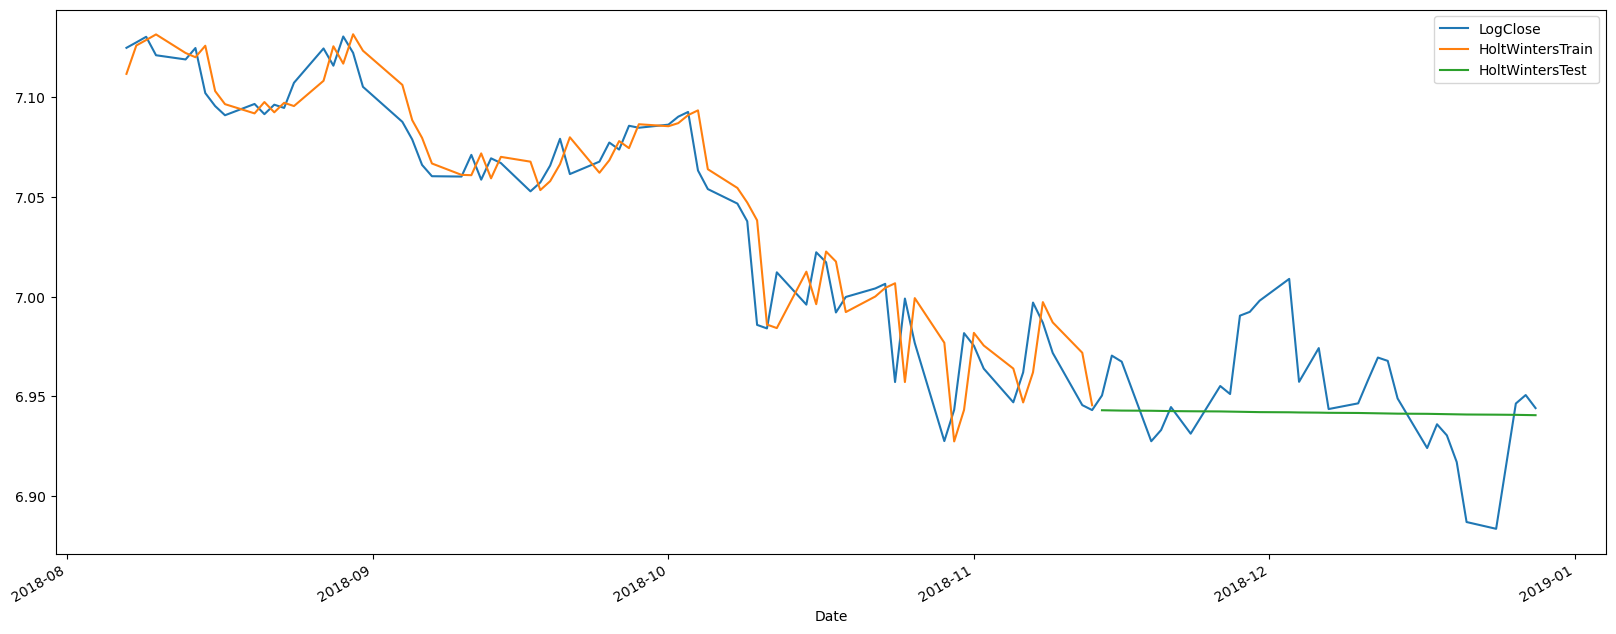

In [29]:
goog.iloc[-100:][['LogClose','HoltWintersTrain','HoltWintersTest']].plot(figsize = (20,8));

In [31]:
"""the predictions are a straight line in test set since the level alpha is approx 1 which is to say it is just copying the last known value.
trend is also close to 0 meaning no trend is detected and is a horizontal line.
for train data, it is just copying the last known value.
this proves that it is just doing naive forecast
"""

'the predictions are a straight line in test set since the level alpha is approx 1 which is to say it is just copying the last known value.\ntrend is also close to 0 meaning no trend is detected and is a horizontal line.\nfor train data, it is just copying the last known value.\nthis proves that it is just doing naive forecast\n'

In [34]:
goog.loc[test_idx, "Naive"] = train.iloc[-1]['LogClose']

In [35]:
goog.tail(n=40)

,Close,LogClose,HoltWintersTrain,HoltWintersTest,Naive
Date,,,,,
2018-10-31,1076.770020,6.981721,6.943244,NaN,NaN
2018-11-01,1070.000000,6.975414,6.981857,NaN,NaN
2018-11-02,1057.790039,6.963937,6.975514,NaN,NaN
2018-11-05,1040.089966,6.947062,6.963971,NaN,NaN
2018-11-06,1055.810059,6.962064,6.947001,NaN,NaN
2018-11-07,1093.390015,6.997038,6.962087,NaN,NaN
2018-11-08,1082.400024,6.986936,6.997260,NaN,NaN
2018-11-09,1066.150024,6.971809,6.987099,NaN,NaN
2018-11-12,1038.630005,6.945658,6.971886,NaN,NaN


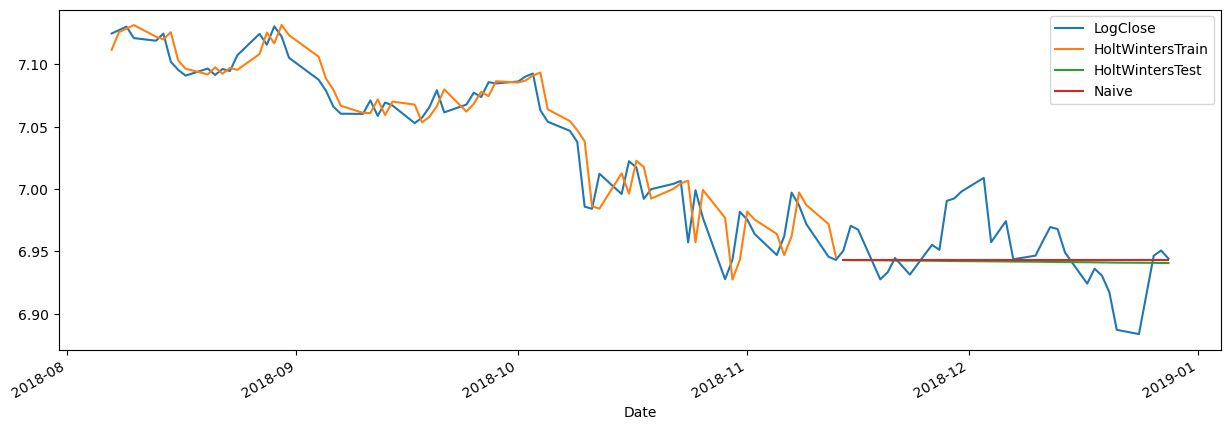

In [37]:
goog.iloc[-100:][['LogClose','HoltWintersTrain','HoltWintersTest','Naive']].plot(figsize=(15,5));

In [40]:
r2_score(goog.loc[test_idx,'LogClose'],goog.loc[test_idx,'HoltWintersTest'])

-0.07114166245205311

In [41]:
r2_score(goog.loc[test_idx,'LogClose'],goog.loc[test_idx,'Naive'])

-0.06454209862026317

In [42]:
"""naive and holt winters score are approx same
since both are less than 0, it means SSE is higher than variance of the data
"""

'naive and holt winters score are approx same\nsince both are less than 0, it means SSE is higher than variance of the data\n'

In [43]:
from sklearn.metrics import mean_squared_error

In [44]:
mean_squared_error(goog.loc[test_idx,'LogClose'],goog.loc[test_idx,'HoltWintersTest'])

0.0008319510181650729

In [46]:
mean_squared_error(goog.loc[test_idx,'LogClose'],goog.loc[test_idx,'Naive'])

0.0008268251659629149